# Parallel execution of parameter scan

## 1D Run

In [1]:
import xarray as xr

import numpy as np

import time as tm

In [33]:
import warnings
warnings.simplefilter(action='ignore', category=(RutimeWarning, FutureWarning))

NameError: name 'RutimeWarning' is not defined

In [3]:
from func_parallel import run_model_test

In [4]:
from multiprocessing import Pool

In [5]:
def generate_iterable_parscan(parameter, par_range):
    return [{parameter:val} for val in par_range]

In [6]:
iter_scan = generate_iterable_parscan('N0__value', np.linspace(0.001,0.2, 5))

In [7]:
run_model_test(iter_scan[4])

Event triggered at t = [15.70466666]


<xarray.Dataset> Size: 3MB
Dimensions:                                         (zoo: 4, time: 5000,
                                                     phyto: 3, full: 7, clock: 2)
Coordinates:
  * clock                                           (clock) int64 16B 0 1
  * phyto                                           (phyto) float64 24B 0.63 ...
  * time                                            (time) float64 40kB 0.0 ....
  * zoo                                             (zoo) float64 32B 6.3 ......
Dimensions without coordinates: full
Data variables: (12/57)
    Core__solver_type                               <U9 36B 'solve_ivp'
    GGE__R                                          float64 8B 0.45
    GGE__alpha                                      float64 8B 0.7
    GGE__assimilated_consumer                       <U1 4B 'Z'
    GGE__assimilation_value                         (zoo, time) float64 160kB ...
    GGE__egested_detritus                           <U1 4B 'N'
    ...                                              ...
    Phytoplankton__phyto_index                      (phyto) float64 24B 0.63 ...
    Time__time_input                                (time) int64 40kB 0 ... 4999
    Zooplankton__biomass                            (zoo, time) float64 160kB ...
    Zooplankton__biomass_init                       (zoo) float64 32B 0.1 ......
    Zooplankton__biomass_label                      <U1 4B 'Z'
    Zooplankton__zoo_index                          (zoo) float64 32B 6.3 ......

In [8]:
import time as tm
p = Pool(processes=20)
start = tm.time()
data = p.map(run_model_test, iter_scan)
end = tm.time()
p.close()
print(round(end-start,5),"seconds")

3.0557 seconds
Event triggered at t = [15.70466666]
Event triggered at t = [103.22399276]
Event triggered at t = [299.23585072]
No event detected
No event detected


In [9]:
def unpack_par_scan(iterable):
    var = list(iterable[0].keys())[0]
    i_tot=len(iterable)
    
    dat_out = []
    for dat,i, val in zip(data,range(i_tot),iterable) :
        dat_out.append(dat.assign_coords({var:list(val.values())[0]}).expand_dims(var))

    data_combined = xr.combine_by_coords(dat_out)
    
    return data_combined

In [10]:
outtt = unpack_par_scan(iter_scan)

outtt

<xarray.Dataset> Size: 13MB
Dimensions:                                         (N0__value: 5, zoo: 4,
                                                     time: 5000, phyto: 3,
                                                     full: 7, clock: 2)
Coordinates:
  * N0__value                                       (N0__value) float64 40B 0...
  * clock                                           (clock) int64 16B 0 1
  * phyto                                           (phyto) float64 24B 0.63 ...
  * time                                            (time) float64 40kB 0.0 ....
  * zoo                                             (zoo) float64 32B 6.3 ......
Dimensions without coordinates: full
Data variables: (12/56)
    Core__solver_type                               (N0__value) <U9 180B 'sol...
    GGE__R                                          (N0__value) float64 40B 0...
    GGE__alpha                                      (N0__value) float64 40B 0...
    GGE__assimilated_consumer                       (N0__value) <U1 20B 'Z' ....
    GGE__assimilation_value                         (N0__value, zoo, time) float64 800kB ...
    GGE__egested_detritus                           (N0__value) <U1 20B 'N' ....
    ...                                              ...
    Phytoplankton__phyto_index                      (N0__value, phyto) float64 120B ...
    Time__time_input                                (N0__value, time) int64 200kB ...
    Zooplankton__biomass                            (N0__value, zoo, time) float64 800kB ...
    Zooplankton__biomass_init                       (N0__value, zoo) float64 160B ...
    Zooplankton__biomass_label                      (N0__value) <U1 20B 'Z' ....
    Zooplankton__zoo_index                          (N0__value, zoo) float64 160B ...

In [ ]:
outtt.isel(time=slice(365*9,365*10)).Phytoplankton__biomass.mean(dim="time").plot(xscale='log', y='N0__value')

# 2D Par scan

In [26]:
def generate_iterable_2d_parscan(par1, par_range1, par2, par_range2):
    return [(par1,(val1, par2, generate_iterable_parscan(par2, par_range2))) for val1 in par_range1]

In [27]:
iter_scan_2d = generate_iterable_2d_parscan('N0__value', np.linspace(0.001,0.01, 5),
                             'HigherOrderMortality__rate', np.linspace(0.001,0.01, 5))

In [28]:
import time as tm
p = Pool(processes=20)
start = tm.time()
data2d = []
for iter_par1, (iter_val1, iter_par2, iter_vals2) in iter_scan_2d:
    data2d.append((iter_par1, (iter_val1, iter_par2, p.map(run_model_test, iter_vals2))))

end = tm.time()
p.close()
print(round(end-start,5),"seconds")

21.86126 seconds
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected


In [29]:
unpack_2d_par_scan(data2d)

<xarray.Dataset> Size: 63MB
Dimensions:                                         (
                                                     HigherOrderMortality__rate: 5,
                                                     N0__value: 5, zoo: 4,
                                                     time: 5000, phyto: 3,
                                                     full: 7, clock: 2)
Coordinates:
  * HigherOrderMortality__rate                      (HigherOrderMortality__rate) float64 40B ...
  * N0__value                                       (N0__value) float64 40B 0...
  * clock                                           (clock) int64 16B 0 1
  * phyto                                           (phyto) float64 24B 0.63 ...
  * time                                            (time) float64 40kB 0.0 ....
  * zoo                                             (zoo) float64 32B 6.3 ......
Dimensions without coordinates: full
Data variables: (12/55)
    Core__solver_type                               (HigherOrderMortality__rate, N0__value) <U9 900B ...
    GGE__R                                          (HigherOrderMortality__rate, N0__value) float64 200B ...
    GGE__alpha                                      (HigherOrderMortality__rate, N0__value) float64 200B ...
    GGE__assimilated_consumer                       (HigherOrderMortality__rate, N0__value) <U1 100B ...
    GGE__assimilation_value                         (HigherOrderMortality__rate, N0__value, zoo, time) float64 4MB ...
    GGE__egested_detritus                           (HigherOrderMortality__rate, N0__value) <U1 100B ...
    ...                                              ...
    Phytoplankton__phyto_index                      (HigherOrderMortality__rate, N0__value, phyto) float64 600B ...
    Time__time_input                                (HigherOrderMortality__rate, N0__value, time) int64 1MB ...
    Zooplankton__biomass                            (HigherOrderMortality__rate, N0__value, zoo, time) float64 4MB ...
    Zooplankton__biomass_init                       (HigherOrderMortality__rate, N0__value, zoo) float64 800B ...
    Zooplankton__biomass_label                      (HigherOrderMortality__rate, N0__value) <U1 100B ...
    Zooplankton__zoo_index                          (HigherOrderMortality__rate, N0__value, zoo) float64 800B ...

In [19]:
dats_out = []
for var, (val, var2, dat) in data2d:

    dat_out = []
    for out in dat:
        #print(out)
        dat_out.append(out.assign_coords({var:val, var2:out[var2].values}).expand_dims(var).expand_dims(var2))

    data_combined = xr.combine_by_coords(dat_out)
        
    dats_out.append(data_combined)

xr.combine_by_coords(dats_out)

<xarray.Dataset> Size: 63MB
Dimensions:                                         (
                                                     HigherOrderMortality__rate: 5,
                                                     N0__value: 5, zoo: 4,
                                                     time: 5000, phyto: 3,
                                                     full: 7, clock: 2)
Coordinates:
  * HigherOrderMortality__rate                      (HigherOrderMortality__rate) float64 40B ...
  * N0__value                                       (N0__value) float64 40B 0...
  * clock                                           (clock) int64 16B 0 1
  * phyto                                           (phyto) float64 24B 0.63 ...
  * time                                            (time) float64 40kB 0.0 ....
  * zoo                                             (zoo) float64 32B 6.3 ......
Dimensions without coordinates: full
Data variables: (12/55)
    Core__solver_type                               (HigherOrderMortality__rate, N0__value) <U9 900B ...
    GGE__R                                          (HigherOrderMortality__rate, N0__value) float64 200B ...
    GGE__alpha                                      (HigherOrderMortality__rate, N0__value) float64 200B ...
    GGE__assimilated_consumer                       (HigherOrderMortality__rate, N0__value) <U1 100B ...
    GGE__assimilation_value                         (HigherOrderMortality__rate, N0__value, zoo, time) float64 4MB ...
    GGE__egested_detritus                           (HigherOrderMortality__rate, N0__value) <U1 100B ...
    ...                                              ...
    Phytoplankton__phyto_index                      (HigherOrderMortality__rate, N0__value, phyto) float64 600B ...
    Time__time_input                                (HigherOrderMortality__rate, N0__value, time) int64 1MB ...
    Zooplankton__biomass                            (HigherOrderMortality__rate, N0__value, zoo, time) float64 4MB ...
    Zooplankton__biomass_init                       (HigherOrderMortality__rate, N0__value, zoo) float64 800B ...
    Zooplankton__biomass_label                      (HigherOrderMortality__rate, N0__value) <U1 100B ...
    Zooplankton__zoo_index                          (HigherOrderMortality__rate, N0__value, zoo) float64 800B ...

# UNPACK DATA

In [12]:
def unpack_2d_par_scan(datasets):
    dats_out = []
    for var, (val, var2, dat) in datasets:
    
        dat_out = []
        for out in dat:
            #print(out)
            dat_out.append(out.assign_coords({var:val, var2:out[var2].values}).expand_dims(var).expand_dims(var2))
    
        data_combined = xr.combine_by_coords(dat_out)
            
        dats_out.append(data_combined)
    
    data_combined_2d = xr.combine_by_coords(dats_out)

    return data_combined_2d

In [13]:
mort_n0_scan = unpack_2d_par_scan(data2d)

NameError: name 'data2d' is not defined

# Start scanning and plotting results!

In [30]:
n0_mort_scan_input = generate_iterable_2d_parscan('N0__value', np.linspace(0.001,0.2, 25),
                             'HigherOrderMortality__rate', np.linspace(0.0001,0.05, 25))

In [31]:
def run_model_get_output(iterable_in):

    p = Pool(processes=20)
    print("pool started")
    start = tm.time()
    data2d = []
    for iter_par1, (iter_val1, iter_par2, iter_vals2) in iterable_in:
        print("running", iter_par1, iter_val1)
        data2d.append((iter_par1, (iter_val1, iter_par2, p.map(run_model_test, iter_vals2))))
    
    end = tm.time()
    p.close()
    print("Full scan done in ",round(end-start,5),"seconds")

    scan_output = unpack_2d_par_scan(data2d)
    return scan_output

In [32]:
mort_n0_scan = run_model_get_output(n0_mort_scan_input)

pool started
running N0__value 0.001


/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5


running N0__value 0.009291666666666667


/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5


running N0__value 0.017583333333333336


...

running N0__value 0.19170833333333337


/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5


running N0__value 0.2


/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5


Full scan done in  371.84228 seconds
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event 

In [34]:
mort_n0_scan.isel(N0__value=0, time=slice(365*9,365*10)).Phytoplankton__biomass.mean(dim="time")

<xarray.DataArray 'Phytoplankton__biomass' (HigherOrderMortality__rate: 25,
                                            phyto: 3)> Size: 600B
array([[           nan,            nan,            nan],
       [5.21771501e-01, 3.74358994e-02, 3.81196734e-01],
       [2.11800949e-01, 1.47618277e-01, 5.56203219e-02],
       [8.12893366e-02, 2.89133673e-01, 1.58651124e-02],
       [3.45658287e-02, 4.42198674e-01, 5.94455540e-03],
       [1.60757680e-02, 6.10094064e-01, 2.64031516e-03],
       [7.88479184e-03, 8.03185521e-01, 1.31371601e-03],
       [3.90911922e-03, 1.02380628e+00, 7.18983263e-04],
       [1.95348317e-03, 1.23998440e+00, 4.27034647e-04],
       [3.37574308e-03, 1.44860810e+00, 2.16467287e-04],
       [1.55783149e-72, 2.08167394e+00, 2.60705577e-07],
       [8.11966861e-83, 2.78175496e+00, 6.65522213e-15],
       [           nan,            nan,            nan],
       [           nan,            nan,            nan],
       [           nan,            nan,            nan],
       [           nan,            nan,            nan],
       [           nan,            nan,            nan],
       [           nan,            nan,            nan],
       [           nan,            nan,            nan],
       [           nan,            nan,            nan],
       [           nan,            nan,            nan],
       [           nan,            nan,            nan],
       [           nan,            nan,            nan],
       [           nan,            nan,            nan],
       [           nan,            nan,            nan]])
Coordinates:
  * HigherOrderMortality__rate  (HigherOrderMortality__rate) float64 200B 0.0...
    N0__value                   float64 8B 0.001
  * phyto                       (phyto) float64 24B 0.63 6.3 63.0

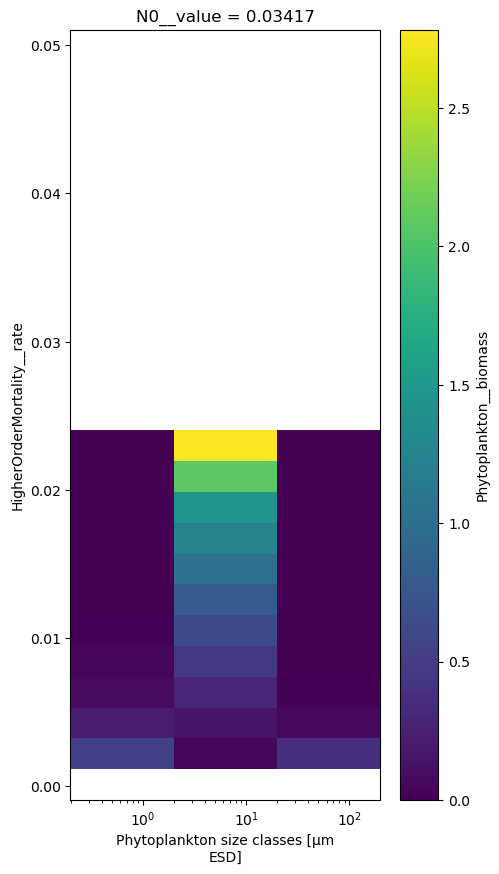

In [35]:
mort_n0_scan.isel(N0__value=4, time=slice(365*9,365*10)).Phytoplankton__biomass.mean(dim="time").plot(xscale='log', y='HigherOrderMortality__rate')

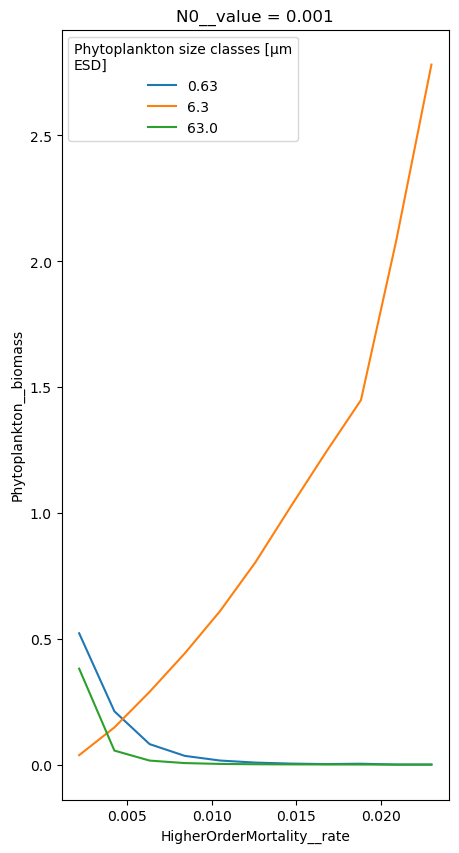

In [39]:
mort_n0_scan.isel(N0__value=0, time=slice(365*9,365*10)).Phytoplankton__biomass.mean(dim="time").plot.line(x='HigherOrderMortality__rate')

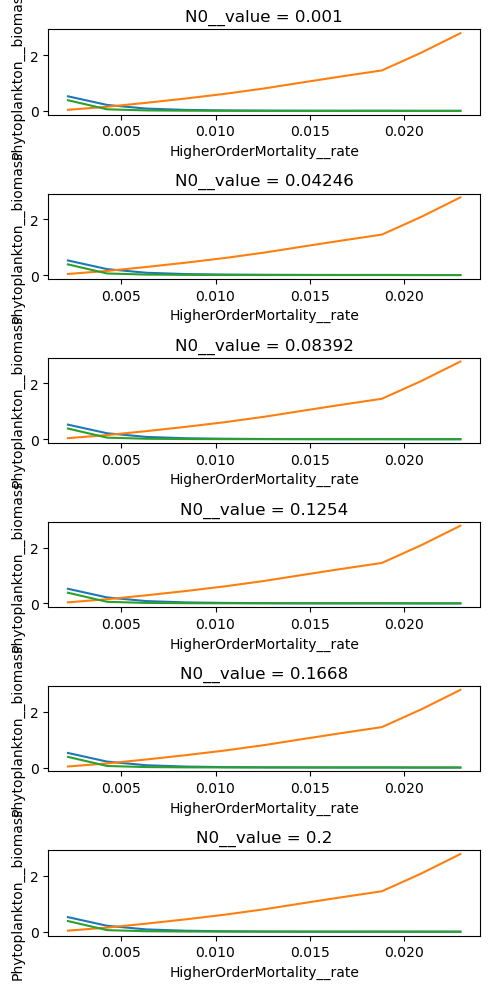

In [49]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 10]

parsetind_toplot = [0,5,10,15,20,24]

fig, ax = plt.subplots(len(parsetind_toplot))
                       
for ind, val in enumerate(parsetind_toplot):
    (mort_n0_scan
        .isel(time=slice(365*9,365*10), N0__value=val)
        .Phytoplankton__biomass.mean(dim="time").plot.line(x='HigherOrderMortality__rate', ax=ax[ind], add_legend=False))#, ylim=(0,1)))

plt.tight_layout()